### Loading Dataset from Kegal

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# theme
sns.set_theme('notebook', 'white', color_codes=True)

filePath = "Salary_Data.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, "mohithsairamreddy/salary-data", filePath
)
print(df.info())
print(df.describe())
print(f"Shape: {df.shape}")

c:\Projects\Python\python practice code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB
None
               Age  Years of Experience         Salary
count  6702.000000          6701.000000    6699.000000
mean     33.620859             8.094687  115326.964771
std       7.614633             6.059003   52786.183911
min      21.000000             0.000000     350.000000
25%      28.000000             3.000000   70000.000000
50%      32.000000             7.000000  115000.000000
75%      38.000000            12.000000  160000.000000
max      6

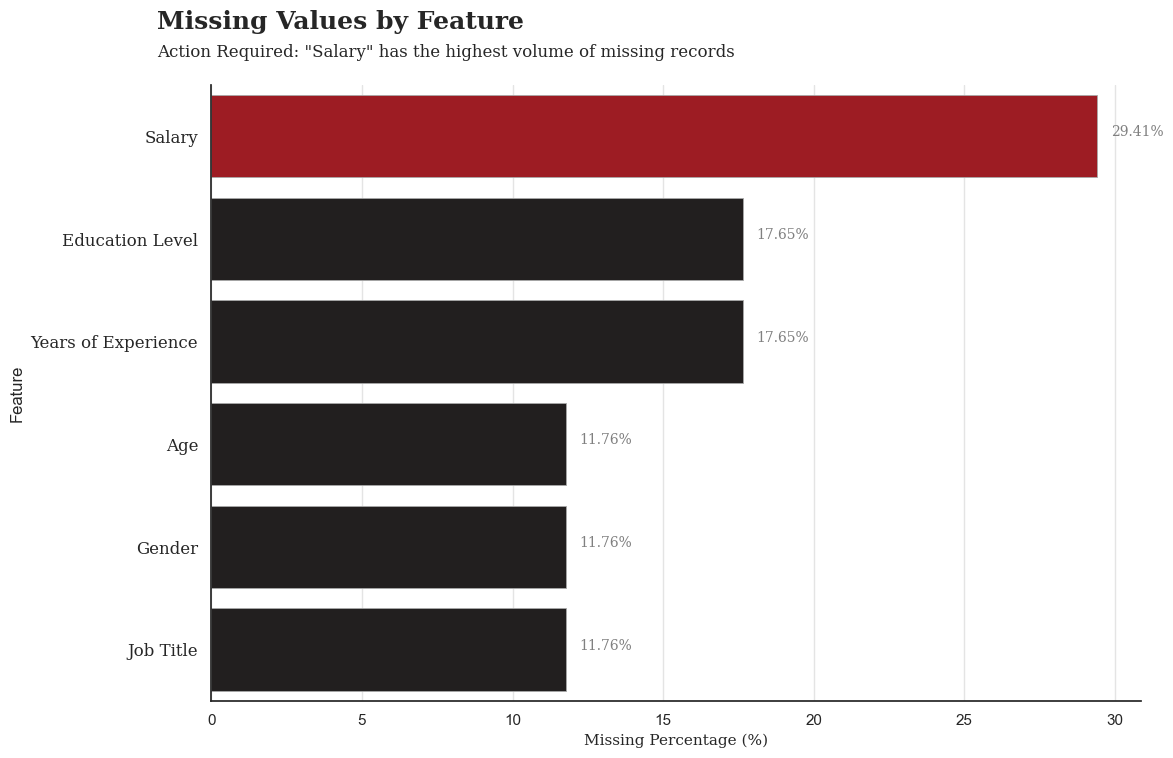

In [2]:
# Missing Value Analysis
# print("MISSING VALUE ANALYSIS")
# print("=" * 40)
missing_data = pd.DataFrame(
    {
        'Feature': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Percentage': (df.isnull().sum() / df.isnull().sum().sum() * 100).round(2),
        'Data_Type': df.dtypes,
    }
)
# print(missing_data)
# print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Visualize missing values
# missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    by='Percentage', ascending=False
)

color_map = ['#221f1f' for _ in range(len(missing_data))]
if len(color_map) > 0:
    color_map[0] = '#b20710'
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=missing_data,
    x='Percentage',
    y='Feature',
    ax=ax,
    palette=color_map,
    hue='Feature',
    edgecolor='darkgray',
    linewidth=0.6,
)
for i, val in enumerate(missing_data.Percentage):
    ax.annotate(
        f'{val:.2f}%',
        xy=(val + 0.45, i),
        fontweight='light',
        fontfamily='serif',
        color='gray',
        fontsize=10,
    )
ax.set_yticks(missing_data['Feature'])
ax.set_yticklabels(missing_data['Feature'], fontfamily='serif', fontsize=12)
ax.grid(axis='x', linestyle='-', alpha=0.6, color='lightgray')

ax.set_xlabel('Missing Percentage (%)', fontsize=11, fontfamily='serif')
fig.text(
    0.08,
    0.95,
    'Missing Values by Feature',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
)
worst_column = missing_data['Feature'].iloc[0] if not missing_data.empty else "None"
fig.text(
    0.08,
    0.915,
    f'Action Required: "{worst_column}" has the highest volume of missing records',
    fontsize=12,
    fontweight='light',
    fontfamily='serif',
)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)


plt.show()

In [3]:
# Redefining column names
df.rename(
    columns={
        'Years of Experience': 'Experience',
        "Education Level": 'Education',
        'Job Title': 'Job',
    },
    inplace=True,
)
print(df.columns)

# Convert numeric columns to appropriate data types
for col in ['Age', 'Experience', 'Salary']:
    df[col] = (
        pd.to_numeric(df[col], errors='coerce', downcast='integer')
        .fillna(df[col].mean())
        .abs()
    )
# convert categorical columns to string type
for col in ['Education', 'Job', 'Gender']:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].fillna(df[col].mode()[0])
print(df.info())

Index(['Age', 'Gender', 'Education', 'Job', 'Experience', 'Salary'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         6704 non-null   float64
 1   Gender      6704 non-null   str    
 2   Education   6704 non-null   str    
 3   Job         6704 non-null   str    
 4   Experience  6704 non-null   float64
 5   Salary      6704 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB
None


CATEGORICAL FEATURES:
      Gender          Education                    Job
0       male         bachelor's      software engineer
1     female           master's           data analyst
2       male                phd         senior manager
3     female         bachelor's        sales associate
4       male           master's               director
...      ...                ...                    ...
6699  female                phd  director of marketing
6700    male        high school        sales associate
6701  female  bachelor's degree      financial manager
6702    male    master's degree      marketing manager
6703  female        high school        sales executive

[6704 rows x 3 columns]


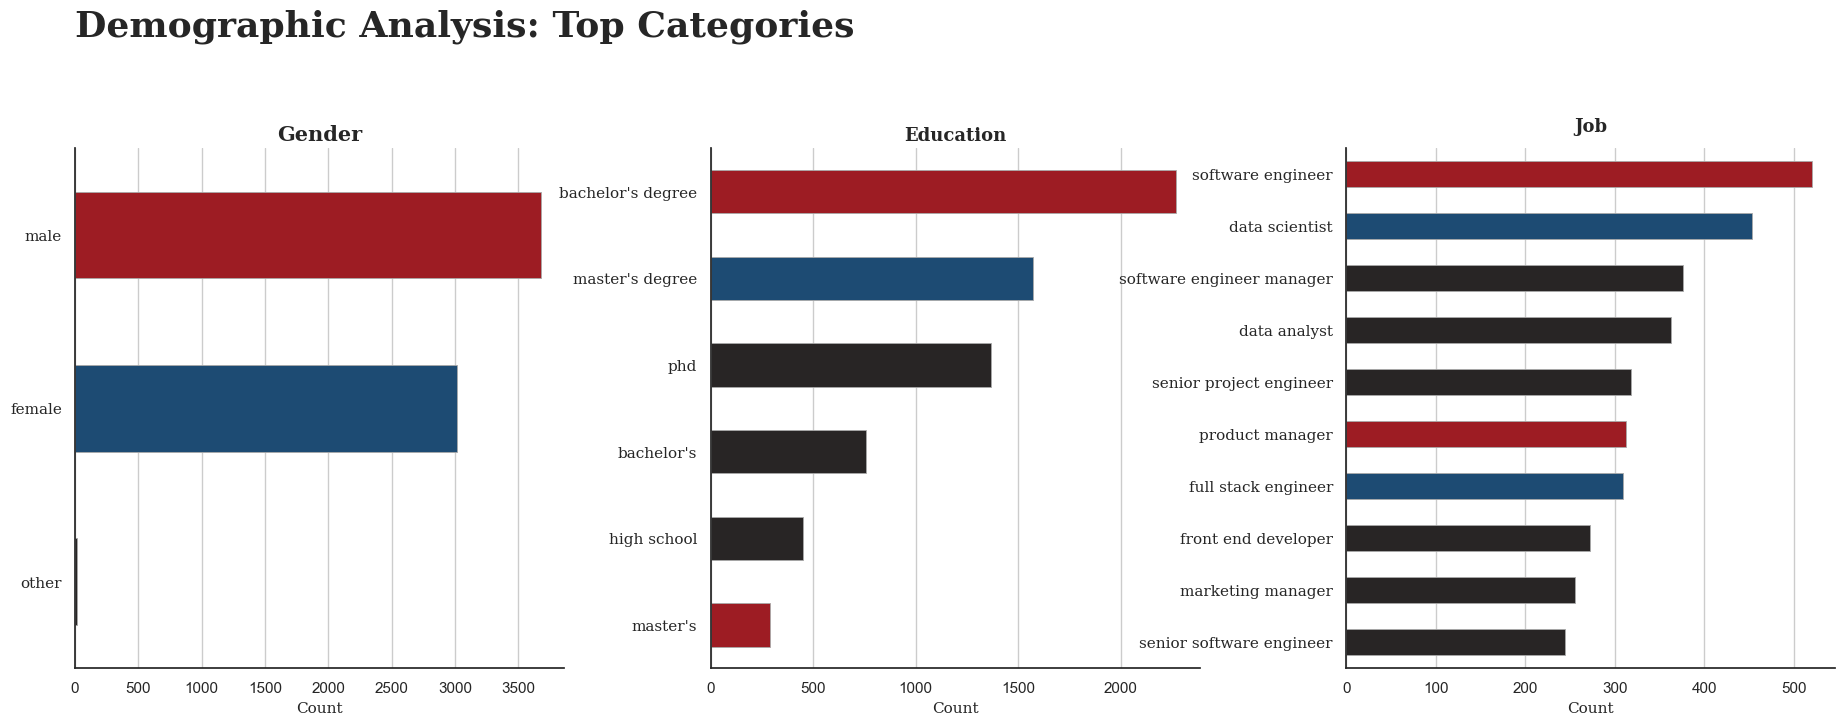

In [4]:
# Categorical Features Analysis
categorical_features = df.select_dtypes(include=['object', 'category', 'str'])
print("CATEGORICAL FEATURES:")
print(categorical_features)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

fig.subplots_adjust(left=0.06, right=0.94, top=0.80, bottom=0.15, wspace=0.3)

fig.text(
    0.06,
    0.94,
    'Demographic Analysis: Top Categories',
    fontsize=26,
    fontweight='bold',
    fontfamily='serif',
)

color_map = ["#282525ef" for _ in range(5)]
color_map[0] = '#b20710'
color_map[1] = '#0f4c81'

# Gender Distribution
gender = df['Gender'].value_counts().reset_index()
gender.columns = ['Gender', 'Count']
sns.barplot(
    data=gender,
    x='Count',
    y='Gender',
    width=0.5,
    edgecolor='darkgray',
    linewidth=0.6,
    palette=color_map[: len(gender)],
    hue='Gender',
    ax=axes[0],
)

axes[0].set_title('Gender', fontsize=15, fontweight='bold', fontfamily='serif')
axes[0].set_ylabel('')  # Clear redundant y-axis label
axes[0].set_xlabel('Count', fontfamily='serif', fontsize=11)
axes[0].set_yticklabels(gender['Gender'], fontfamily='serif')

axes[0].grid(axis='x', linestyle='-', alpha=0.4, color='gray')

# Cleaning borders
for s in ['top', 'right']:
    axes[0].spines[s].set_visible(False)

# Education Distribution
education = df['Education'].value_counts().reset_index()
education.columns = ['Education', 'Count']
sns.barplot(
    data=education,
    x='Count',
    y='Education',
    width=0.5,
    edgecolor='darkgray',
    linewidth=0.6,
    palette=color_map[: len(education)],
    hue='Education',
    ax=axes[1],
)
axes[1].set_title('Education', fontsize=13, fontweight='bold', fontfamily='serif')
axes[1].set_ylabel('')  # Clear
axes[1].set_xlabel('Count', fontfamily='serif', fontsize=11)
axes[1].set_yticklabels(education['Education'], fontfamily='serif')
axes[1].grid(axis='x', linestyle='-', alpha=0.4, color='gray')
for s in ['top', 'right']:
    axes[1].spines[s].set_visible(False)

# Job Distribution
job = df['Job'].value_counts().reset_index()
if job.shape[0] > 10:
    job = job.head(10)
job.columns = ['Job', 'Count']
sns.barplot(
    data=job,
    x='Count',
    y='Job',
    width=0.5,
    edgecolor='darkgray',
    linewidth=0.6,
    palette=color_map[: len(job)],
    hue='Job',
    ax=axes[2],
)
axes[2].set_title('Job', fontsize=13, fontweight='bold', fontfamily='serif', pad=12)
axes[2].set_ylabel('')  # Clear
axes[2].set_xlabel('Count', fontfamily='serif', fontsize=11)
axes[2].set_yticklabels(job['Job'], fontfamily='serif')
axes[2].grid(axis='x', linestyle='-', alpha=0.4, color='gray')
for s in ['top', 'right']:
    axes[2].spines[s].set_visible(False)

CATEGORICAL FEATURES vs SALARY RELATIONSHIP


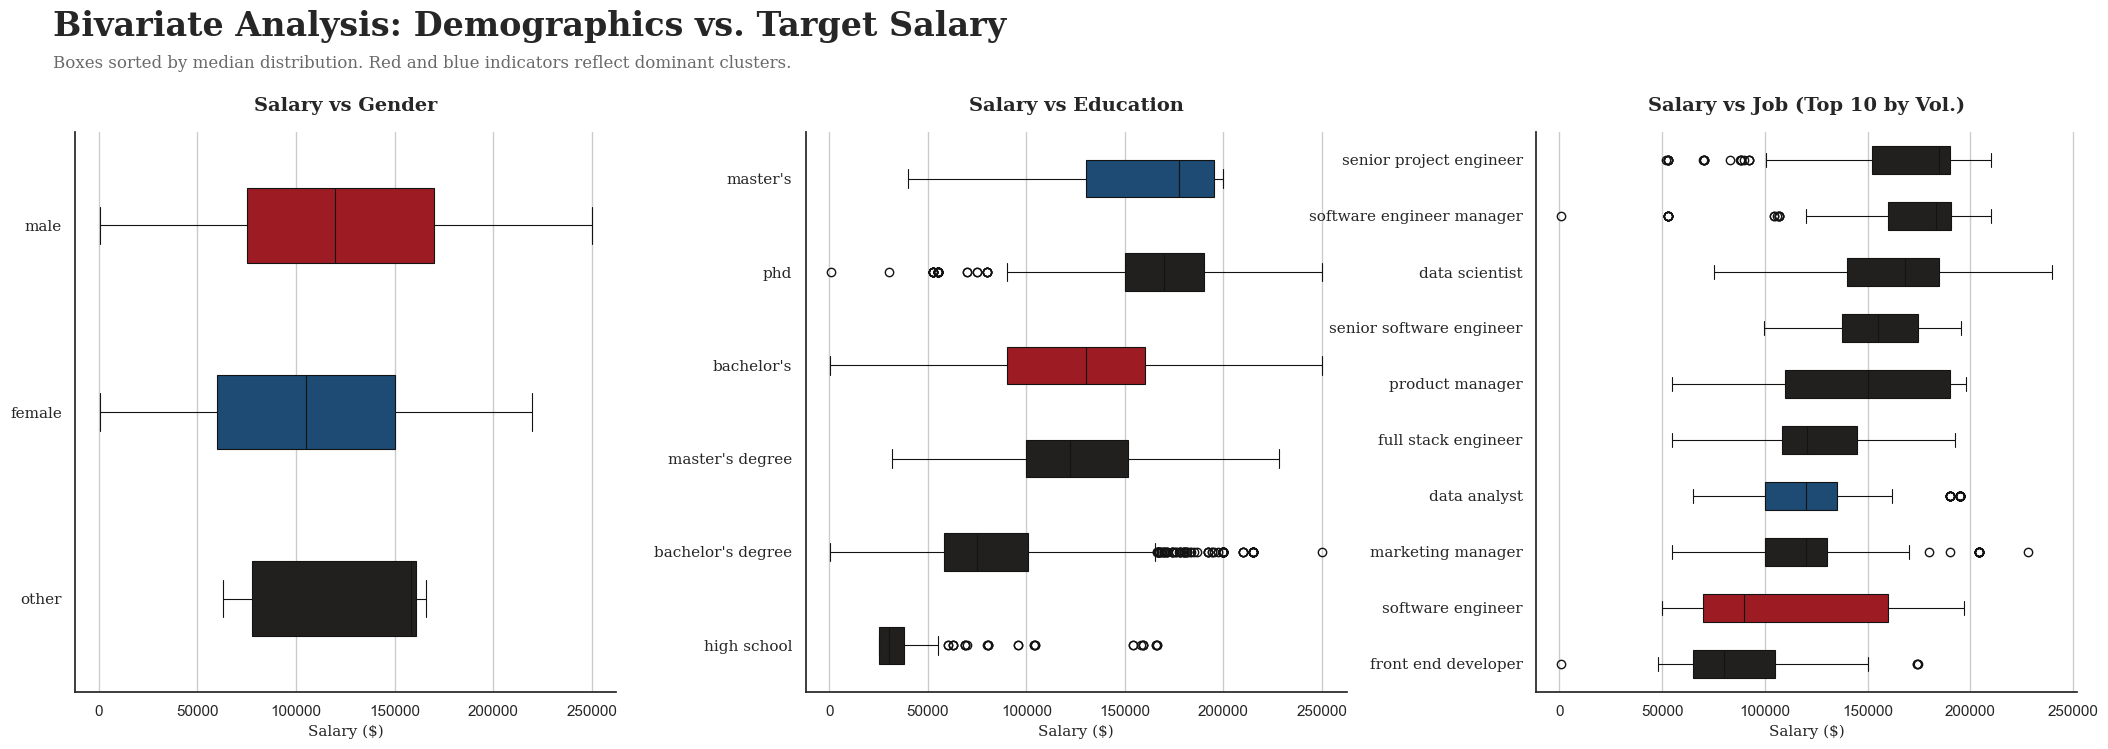

In [5]:
print("CATEGORICAL FEATURES vs SALARY RELATIONSHIP")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

unique_genders = df['Gender'].unique()
color_map_g = ['#221f1f' for _ in range(len(unique_genders))]
if len(color_map_g) > 1:
    color_map_g[0] = '#b20710'
    color_map_g[1] = '#0f4c81'

sns.boxplot(
    data=df,
    x='Salary',
    y='Gender',
    width=0.4,
    linewidth=0.8,
    palette=color_map_g,
    hue='Gender',
    legend=False,
    ax=axes[0],
)
axes[0].set_title(
    'Salary vs Gender', fontsize=14, fontweight='bold', fontfamily='serif', pad=15
)
axes[0].set_xlabel('Salary ($)', fontfamily='serif', fontsize=11)
axes[0].set_ylabel('')
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontfamily='serif', fontsize=11)
axes[0].grid(axis='x', linestyle='-', alpha=0.4, color='gray')

for s in ['top', 'right']:
    axes[0].spines[s].set_visible(False)


edu_order = (
    df.groupby('Education')['Salary'].median().sort_values(ascending=False).index
)

color_map_e = ['#221f1f' for _ in range(len(edu_order))]
if len(color_map_e) > 1:
    color_map_e[0] = '#b20710'
    color_map_e[1] = '#0f4c81'

sns.boxplot(
    data=df,
    x='Salary',
    y='Education',
    order=edu_order,
    width=0.4,
    linewidth=0.8,
    palette=color_map_e,
    hue='Education',
    legend=False,
    ax=axes[1],
)
axes[1].set_title(
    'Salary vs Education', fontsize=14, fontweight='bold', fontfamily='serif', pad=15
)
axes[1].set_xlabel('Salary ($)', fontfamily='serif', fontsize=11)
axes[1].set_ylabel('')
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontfamily='serif', fontsize=11)
axes[1].grid(axis='x', linestyle='-', alpha=0.4, color='gray')

for s in ['top', 'right']:
    axes[1].spines[s].set_visible(False)


top_10_jobs = df['Job'].value_counts().head(10).index
df_top_jobs = df[df['Job'].isin(top_10_jobs)]

job_order = (
    df_top_jobs.groupby('Job')['Salary'].median().sort_values(ascending=False).index
)

color_map_j = ['#221f1f' for _ in range(len(job_order))]
if len(color_map_j) > 1:
    color_map_j[0] = '#b20710'
    color_map_j[1] = '#0f4c81'

sns.boxplot(
    data=df_top_jobs,
    x='Salary',
    y='Job',
    order=job_order,
    width=0.5,
    linewidth=0.8,
    palette=color_map_j,
    hue='Job',
    legend=False,
    ax=axes[2],
)
axes[2].set_title(
    'Salary vs Job (Top 10 by Vol.)',
    fontsize=14,
    fontweight='bold',
    fontfamily='serif',
    pad=15,
)
axes[2].set_xlabel('Salary ($)', fontfamily='serif', fontsize=11)
axes[2].set_ylabel('')
axes[2].set_yticklabels(axes[2].get_yticklabels(), fontfamily='serif', fontsize=11)
axes[2].grid(axis='x', linestyle='-', alpha=0.4, color='gray')

for s in ['top', 'right']:
    axes[2].spines[s].set_visible(False)


fig.text(
    0.04,
    0.94,
    'Bivariate Analysis: Demographics vs. Target Salary',
    fontsize=24,
    fontweight='bold',
    fontfamily='serif',
)

fig.text(
    0.04,
    0.90,
    'Boxes sorted by median distribution. Red and blue indicators reflect dominant clusters.',
    fontsize=12,
    fontweight='light',
    fontfamily='serif',
    color='dimgray',
)

fig.subplots_adjust(left=0.05, right=0.96, top=0.82, bottom=0.12, wspace=0.35)

plt.show()

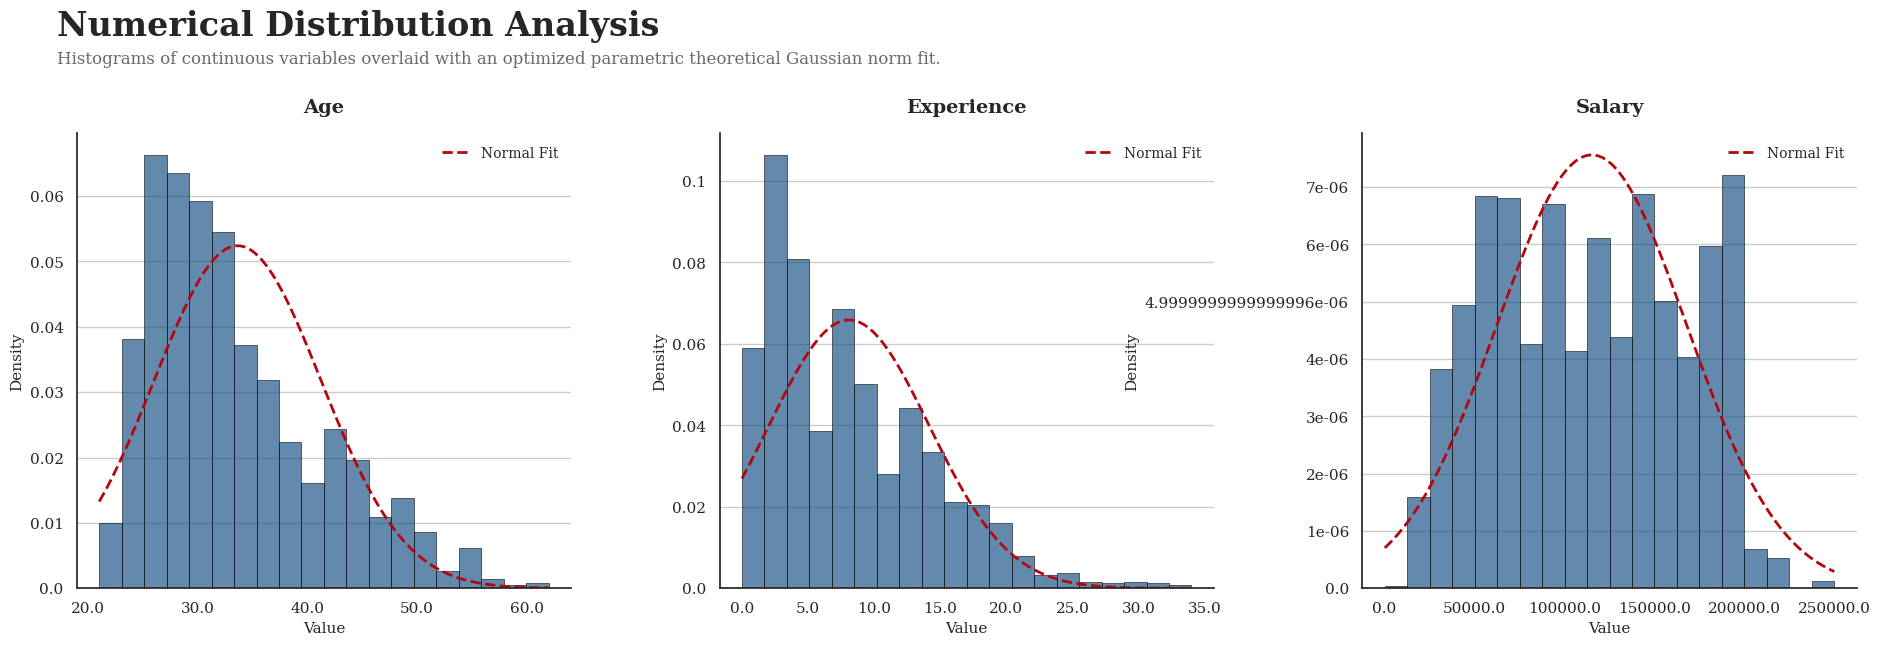

In [6]:
# Numerical Features Analysis
numeric_features = df.select_dtypes(include=[np.number])
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, col in enumerate(numeric_features):
    ax = axes[idx]

    ax.hist(
        df[col],
        bins=20,
        density=True,
        alpha=0.65,
        color=color_map[1],
        edgecolor='black',
        linewidth=0.6,
    )

    mu = df[col].mean()
    sigma = df[col].std()
    x = np.linspace(df[col].min(), df[col].max(), 100)
    y = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    ax.plot(x, y, color=color_map[0], linestyle='--', linewidth=2, label='Normal Fit')

    ax.set_title(col, fontsize=14, fontweight='bold', fontfamily='serif', pad=15)
    ax.set_xlabel('Value', fontfamily='serif', fontsize=11)
    ax.set_ylabel('Density', fontfamily='serif', fontsize=11)
    ax.set_xticklabels(ax.get_xticks(), fontfamily='serif')
    ax.set_yticklabels(ax.get_yticks(), fontfamily='serif')

    ax.legend(frameon=False, prop={'family': 'serif', 'size': 10})
    ax.grid(axis='y', linestyle='-', alpha=0.4, color='gray')

    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

fig.text(
    0.05,
    0.94,
    'Numerical Distribution Analysis',
    fontsize=24,
    fontweight='bold',
    fontfamily='serif',
)

fig.text(
    0.05,
    0.90,
    'Histograms of continuous variables overlaid with an optimized parametric theoretical Gaussian norm fit.',
    fontsize=12,
    fontweight='light',
    fontfamily='serif',
    color='dimgray',
)

fig.subplots_adjust(left=0.06, right=0.95, top=0.80, bottom=0.15, wspace=0.3)

plt.show()


OUTLIER DETECTION - IQR METHOD

Age:
  Q1: 28.00, Q3: 38.00, IQR: 10.00
  Lower Bound: 13.00, Upper Bound: 53.00
  Outliers: 123 (1.83%)

Experience:
  Q1: 3.00, Q3: 12.00, IQR: 9.00
  Lower Bound: 0.00, Upper Bound: 25.50
  Outliers: 75 (1.12%)

Salary:
  Q1: 70000.00, Q3: 160000.00, IQR: 90000.00
  Lower Bound: 0.00, Upper Bound: 295000.00
  Outliers: 0 (0.00%)


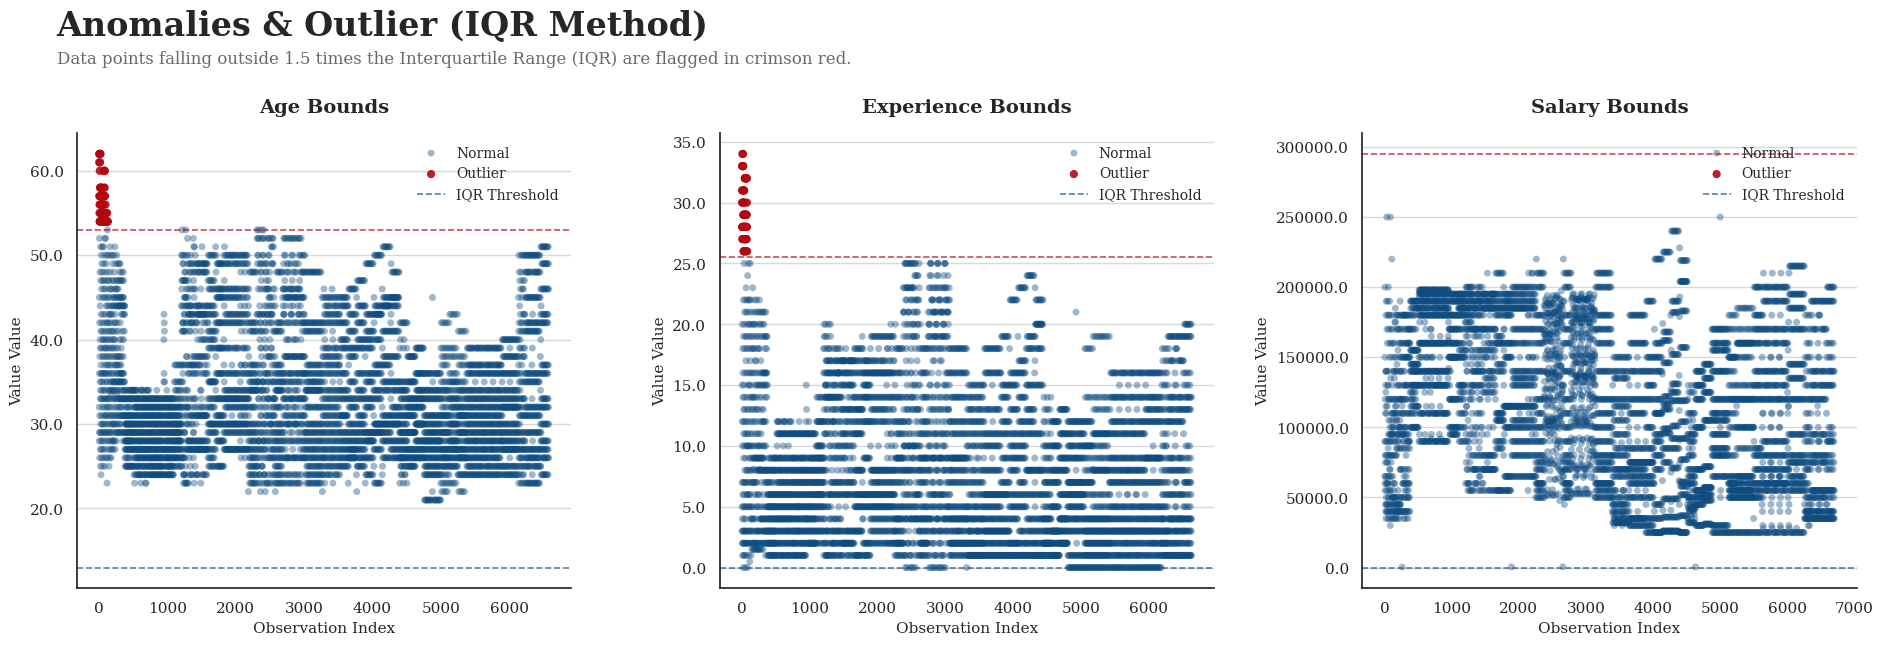


Outlier Summary Table:
   Feature  Lower_Bound  Upper_Bound  Outliers_Count  Outliers_Pct
       Age         13.0         53.0             123      1.834726
Experience          0.0         25.5              75      1.118735
    Salary          0.0     295000.0               0      0.000000


In [7]:
print("\n" + "=" * 60)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 60)
outlier_summary = []

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, feature in enumerate(numeric_features):
    ax = axes[idx]

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    lower_bound = max(0, lower_bound)

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    non_outliers = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    outlier_pct = len(outliers) / len(df) * 100

    print(f"\n{feature}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Outliers: {len(outliers)} ({outlier_pct:.2f}%)")

    outlier_summary.append(
        {
            'Feature': feature,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outliers_Count': len(outliers),
            'Outliers_Pct': outlier_pct,
        }
    )

    # Plot normal points and outliers using a uniform reset index scale
    ax.scatter(
        range(len(non_outliers)),
        non_outliers[feature],
        alpha=0.4,
        s=25,
        label='Normal',
        color=color_map[1],
        edgecolor='none',
    )
    ax.scatter(
        range(len(outliers)),
        outliers[feature],
        alpha=0.9,
        s=35,
        label='Outlier',
        color=color_map[0],
        edgecolor='none',
    )

    # Boundary thresholds
    ax.axhline(
        lower_bound,
        color=color_map[1],
        linestyle='--',
        linewidth=1.2,
        alpha=0.7,
        label='IQR Threshold',
    )
    ax.axhline(
        upper_bound, color=color_map_e[0], linestyle='--', linewidth=1.2, alpha=0.7
    )

    # Custom Subplot Typography
    ax.set_title(
        f'{feature} Bounds', fontsize=14, fontweight='bold', fontfamily='serif', pad=15
    )
    ax.set_ylabel('Value Value', fontfamily='serif', fontsize=11)
    ax.set_xlabel('Observation Index', fontfamily='serif', fontsize=11)
    ax.set_xticklabels(ax.get_xticks().astype(int), fontfamily='serif')
    ax.set_yticklabels(ax.get_yticks(), fontfamily='serif')

    ax.legend(frameon=False, prop={'family': 'serif', 'size': 10}, loc='upper right')
    ax.grid(axis='y', linestyle='-', alpha=0.3, color='gray')

    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

# Main Dashboard Titles
fig.text(
    0.05,
    0.94,
    'Anomalies & Outlier (IQR Method)',
    fontsize=24,
    fontweight='bold',
    fontfamily='serif',
)
fig.text(
    0.05,
    0.90,
    'Data points falling outside 1.5 times the Interquartile Range (IQR) are flagged in crimson red.',
    fontsize=12,
    fontweight='light',
    fontfamily='serif',
    color='dimgray',
)

fig.subplots_adjust(left=0.06, right=0.95, top=0.80, bottom=0.15, wspace=0.3)
plt.show()

print("\nOutlier Summary Table:")
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

In [8]:
# handling dublicate values
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(
    f"Shape before removing duplicates: {df.shape} after removing duplicates: {df_clean.shape}"
)

Shape before removing duplicates: (6704, 6) after removing duplicates: (1792, 6)



------------------------------------------------------------
SALARY STATISTICS - AFTER REMOVING DUPLICATES
------------------------------------------------------------
count      1792.000000
mean     113182.084185
std       51525.505743
min         350.000000
25%       70000.000000
50%      110000.000000
75%      160000.000000
max      250000.000000
Name: Salary, dtype: float64

------------------------------------------------------------
IMPACT ANALYSIS
------------------------------------------------------------
Mean salary change: $2,144.88
Median salary change: $5,000.00
Std salary change: $1,240.99


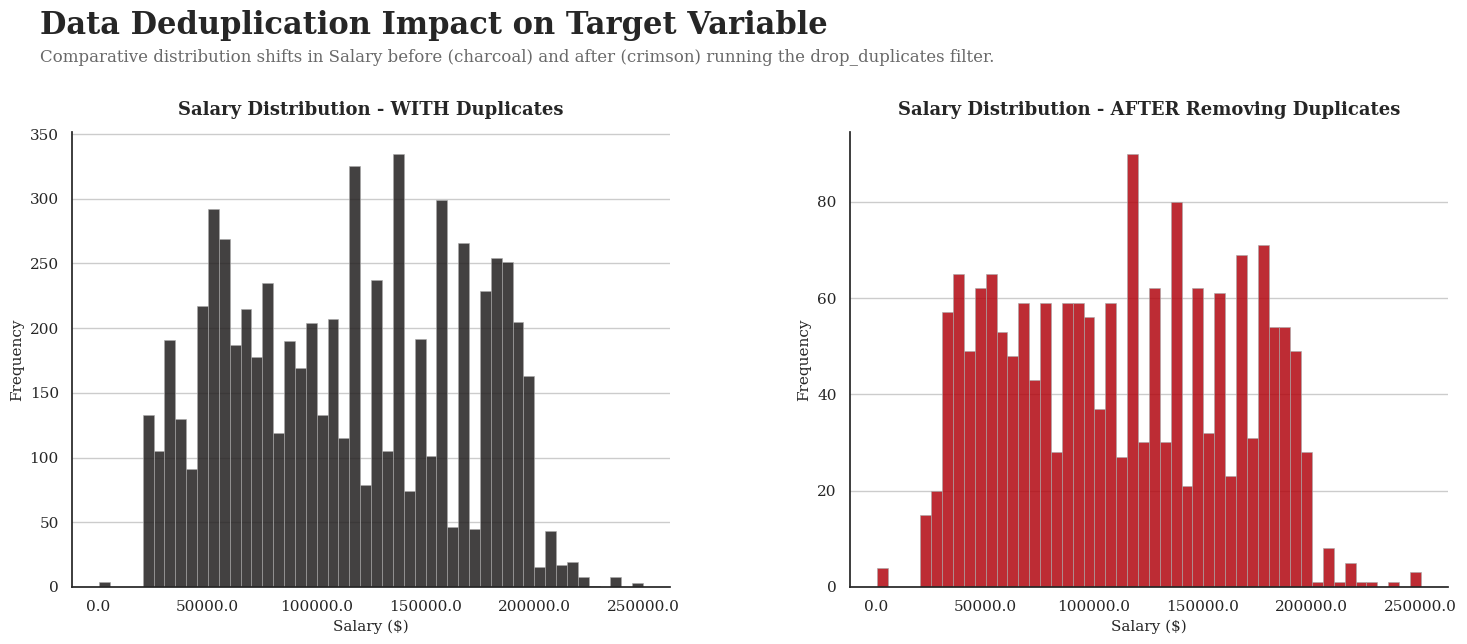

In [9]:
print("\n" + "-" * 60)
print("SALARY STATISTICS - AFTER REMOVING DUPLICATES")
print("-" * 60)
salary_stats_after = df_clean['Salary'].describe()
print(salary_stats_after)

print("\n" + "-" * 60)
print("IMPACT ANALYSIS")
print("-" * 60)
print(f"Mean salary change: ${df['Salary'].mean() - df_clean['Salary'].mean():,.2f}")
print(
    f"Median salary change: ${df['Salary'].median() - df_clean['Salary'].median():,.2f}"
)
print(f"Std salary change: ${df['Salary'].std() - df_clean['Salary'].std():,.2f}")


fig, axes = plt.subplots(1, 2, figsize=(16, 7))


axes[0].hist(
    df['Salary'].dropna(),
    bins=50,
    alpha=0.85,
    color='#221f1f',
    edgecolor='darkgray',
    linewidth=0.5,
)
axes[0].set_title(
    'Salary Distribution - WITH Duplicates',
    fontsize=13,
    fontweight='bold',
    fontfamily='serif',
    pad=12,
)
axes[0].set_xlabel('Salary ($)', fontfamily='serif', fontsize=11)
axes[0].set_ylabel('Frequency', fontfamily='serif', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticks(), fontfamily='serif')
axes[0].set_yticklabels(axes[0].get_yticks().astype(int), fontfamily='serif')
axes[0].grid(axis='y', linestyle='-', alpha=0.4, color='gray')

for s in ['top', 'right']:
    axes[0].spines[s].set_visible(False)


axes[1].hist(
    df_clean['Salary'].dropna(),
    bins=50,
    alpha=0.85,
    color=color_map[0],
    edgecolor='darkgray',
    linewidth=0.5,
)
axes[1].set_title(
    'Salary Distribution - AFTER Removing Duplicates',
    fontsize=13,
    fontweight='bold',
    fontfamily='serif',
    pad=12,
)
axes[1].set_xlabel('Salary ($)', fontfamily='serif', fontsize=11)
axes[1].set_ylabel('Frequency', fontfamily='serif', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticks(), fontfamily='serif')
axes[1].set_yticklabels(axes[1].get_yticks().astype(int), fontfamily='serif')
axes[1].grid(axis='y', linestyle='-', alpha=0.4, color='gray')

for s in ['top', 'right']:
    axes[1].spines[s].set_visible(False)


fig.text(
    0.06,
    0.94,
    'Data Deduplication Impact on Target Variable',
    fontsize=22,
    fontweight='bold',
    fontfamily='serif',
)
fig.text(
    0.06,
    0.90,
    'Comparative distribution shifts in Salary before (charcoal) and after (crimson) running the drop_duplicates filter.',
    fontsize=12,
    fontweight='light',
    fontfamily='serif',
    color='dimgray',
)

fig.subplots_adjust(left=0.08, right=0.94, top=0.80, bottom=0.15, wspace=0.3)
plt.show()

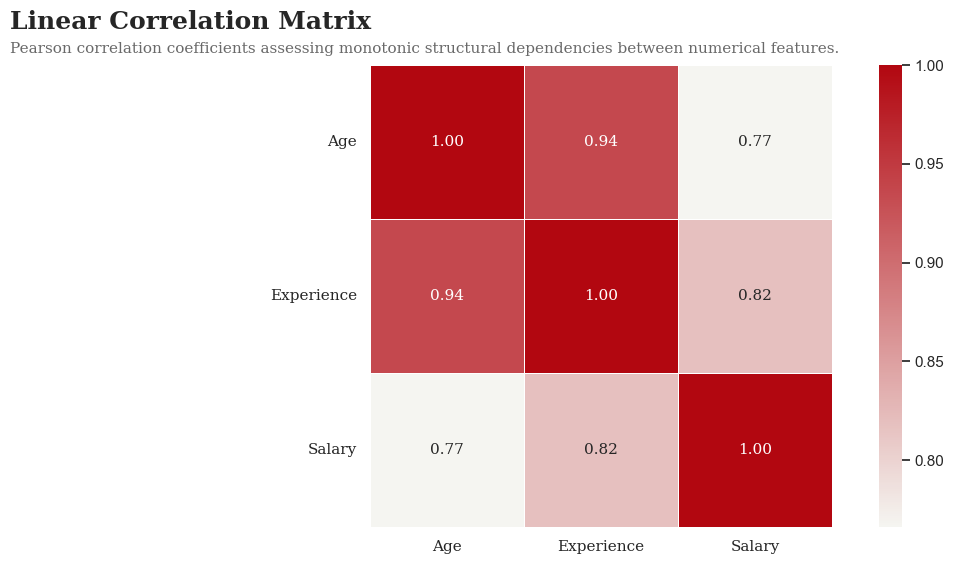

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
df_numeric = df_clean.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()
import matplotlib.colors

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#f5f5f1', '#b20710'])
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=cmap,
    fmt='.2f',
    square=True,
    linewidths=0.6,
    linecolor='white',
    ax=ax,
)


ax.set_xticklabels(corr_matrix.columns, fontfamily='serif', fontsize=11, rotation=0)
ax.set_yticklabels(corr_matrix.index, fontfamily='serif', fontsize=11, rotation=0)


for text in ax.texts:
    text.set_fontfamily('serif')
    text.set_fontsize(11)


fig.text(
    0.06,
    0.94,
    'Linear Correlation Matrix',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
)
fig.text(
    0.06,
    0.90,
    'Pearson correlation coefficients assessing monotonic structural dependencies between numerical features.',
    fontsize=11,
    fontweight='light',
    fontfamily='serif',
    color='dimgray',
)


plt.show()

## Preprocessing all the features and predicting using specific models

In [11]:
# Importing pipelines
from preprocessing_pipeline import (
    create_preprocessor,
    linear_model_pipeline,
    ridge_gridCv_pipeline,
    evaluate_model,
)

In [12]:
# log transformation to handle skewness in salary
df_clean['log_salary'] = np.log1p(df_clean['Salary'])

X = df_clean[['Age', 'Gender', 'Education', 'Experience', 'Job']]
Y = df_clean['log_salary']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"x-train:{X_train.shape}, x-test:{X_test.shape}")
print(f"Y-train:{Y_train.shape}, x-test:{Y_test.shape}")

x-train:(1433, 5), x-test:(359, 5)
Y-train:(1433,), x-test:(359,)


In [19]:
# evaluating models
preprocessor = create_preprocessor()
linear_model = linear_model_pipeline(preprocessor)
linear_model.fit(X_train, Y_train)
y_predict_li = evaluate_model(linear_model, X_test, Y_test)

print(f"Linear R2: {y_predict_li['r2']:.3f} ")
print(f"Linear MAE: {y_predict_li['mae']:.3f}")
print(f"Linear MSE: {y_predict_li['mse']:.3f}")
print(f"Linear RMSE: {y_predict_li['rmse']:.3f}")
print("-" * 30)

Ridge_gridCv = ridge_gridCv_pipeline(preprocessor)
Ridge_gridCv.fit(X_train, Y_train)
y_predict_ridgecv = evaluate_model(Ridge_gridCv, X_test, Y_test)
print(f"GridSearchCV R2: {y_predict_ridgecv['r2']:.3f} ")
print(f"GridSearchCV MAE: {y_predict_ridgecv['mae']:.3f}")
print(f"GridSearchCV MSE:{y_predict_ridgecv['mse']:.3f}")
print(f"GridSearchCV RMSE: {y_predict_ridgecv['rmse']:.3f}")

Linear R2: 0.728 
Linear MAE: 0.200
Linear MSE: 0.070
Linear RMSE: 0.265
------------------------------
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END .....................................model__alpha=1; total time=   0.0s
[CV] END .....................................model__alpha=1; total time=   0.0s
[CV] END .....................................model__alpha=1; total time=   0.0s
[CV] END .....................................model__alpha=1; total time=   0.0s
[CV] END .....................................model__alpha=1; total time=   0.0s
[CV] END .................

In [14]:
print("-" * 30)
sample = pd.DataFrame(
    [
        {
            "Age": 30,
            "Gender": "male",
            "Education": "bachelor's",
            "Job": "software engineer",
            "Experience": 5,
        }
    ]
)

# Predict log-salary, then convert to Salary
sample_log_pred = linear_model.predict(sample)[0]
sample_salary_pred = np.expm1(sample_log_pred)


print(f"Predicted Salary for sample Linear Regression: ${sample_salary_pred:,.2f}")

print(
    f"Predicted Salary for sample GridSearchCV: ${np.expm1(Ridge_gridCv.predict(sample)[0]):,.2f}"
)
print("-" * 30)

------------------------------
Predicted Salary for sample Linear Regression: $88,003.55
Predicted Salary for sample GridSearchCV: $87,976.58
------------------------------


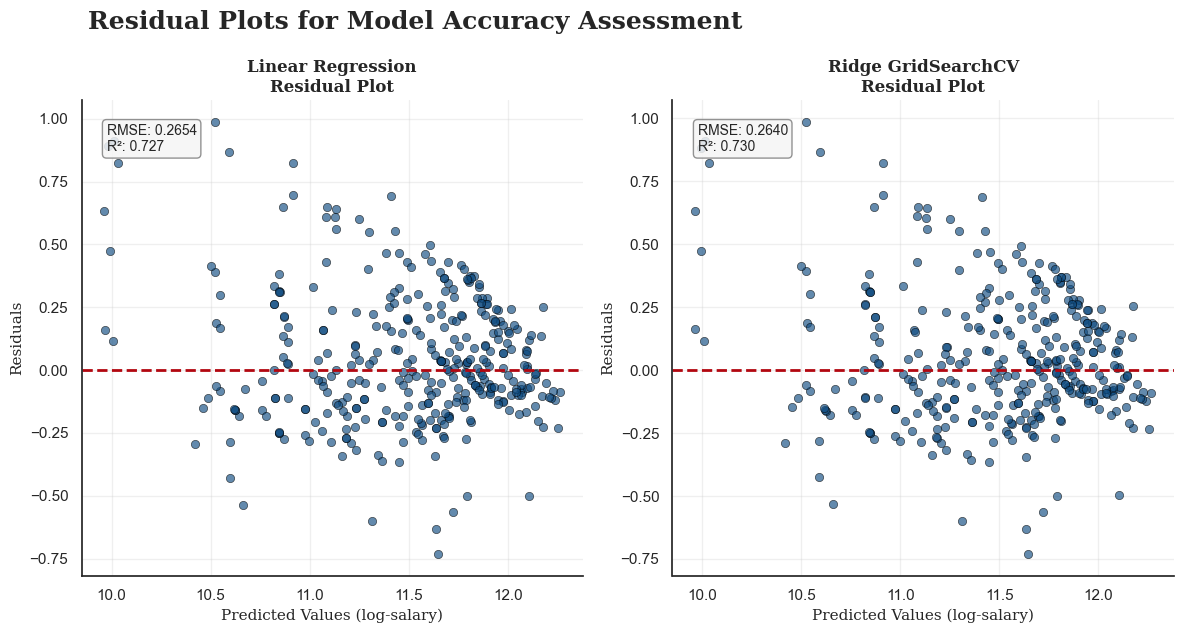


RESIDUAL ANALYSIS - MODEL ACCURACY

Linear Regression:
  Mean of residuals: 0.045811 (should be close to 0)
  Std of residuals: 0.261784
  Min residual: -0.732819
  Max residual: 0.989208

Ridge GridSearchCV:
  Mean of residuals: 0.045347 (should be close to 0)
  Std of residuals: 0.260405
  Min residual: -0.731069
  Max residual: 0.986850


In [16]:
# Extract predictions
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred_li = y_predict_li["predictions"]
y_pred_ridge = y_predict_ridgecv["predictions"]

# Residuals
residuals_linear = Y_test - y_pred_li
residuals_ridge = Y_test - y_pred_ridge

models = ['Linear Regression', 'Ridge GridSearchCV']
predictions = [y_pred_li, y_pred_ridge]
residuals_list = [residuals_linear, residuals_ridge]

# Colors
scatter_color = color_map[1] if len(color_map) > 1 else '#221f1f'
line_color = color_map[0] if len(color_map) > 0 else '#b20710'

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, model_name, y_pred, residuals in zip(axes, models, predictions, residuals_list):
    rmse = root_mean_squared_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.65,
        color=scatter_color,
        edgecolor='black',
        linewidth=0.5,
        ax=ax,
    )

    ax.axhline(y=0, color=line_color, linestyle='--', linewidth=2)

    ax.set_xlabel('Predicted Values (log-salary)', fontfamily='serif', fontsize=11)
    ax.set_ylabel('Residuals', fontfamily='serif', fontsize=11)
    ax.set_title(f'{model_name}\nResidual Plot', fontweight='bold', fontfamily='serif')
    ax.grid(True, alpha=0.3)

    ax.text(
        0.05,
        0.95,
        f'RMSE: {rmse:.4f}\nR²: {r2:.3f}',
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round', facecolor='whitesmoke', edgecolor='gray', alpha=0.85
        ),
    )

    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

fig.text(
    0.08,
    1.02,
    'Residual Plots for Model Accuracy Assessment',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
)

plt.tight_layout()
plt.show()

# Residual summary
print("\n" + "=" * 60)
print("RESIDUAL ANALYSIS - MODEL ACCURACY")
print("=" * 60)

for model_name, residuals in zip(models, residuals_list):
    print(f"\n{model_name}:")
    print(f"  Mean of residuals: {residuals.mean():.6f} (should be close to 0)")
    print(f"  Std of residuals: {residuals.std():.6f}")
    print(f"  Min residual: {residuals.min():.6f}")
    print(f"  Max residual: {residuals.max():.6f}")

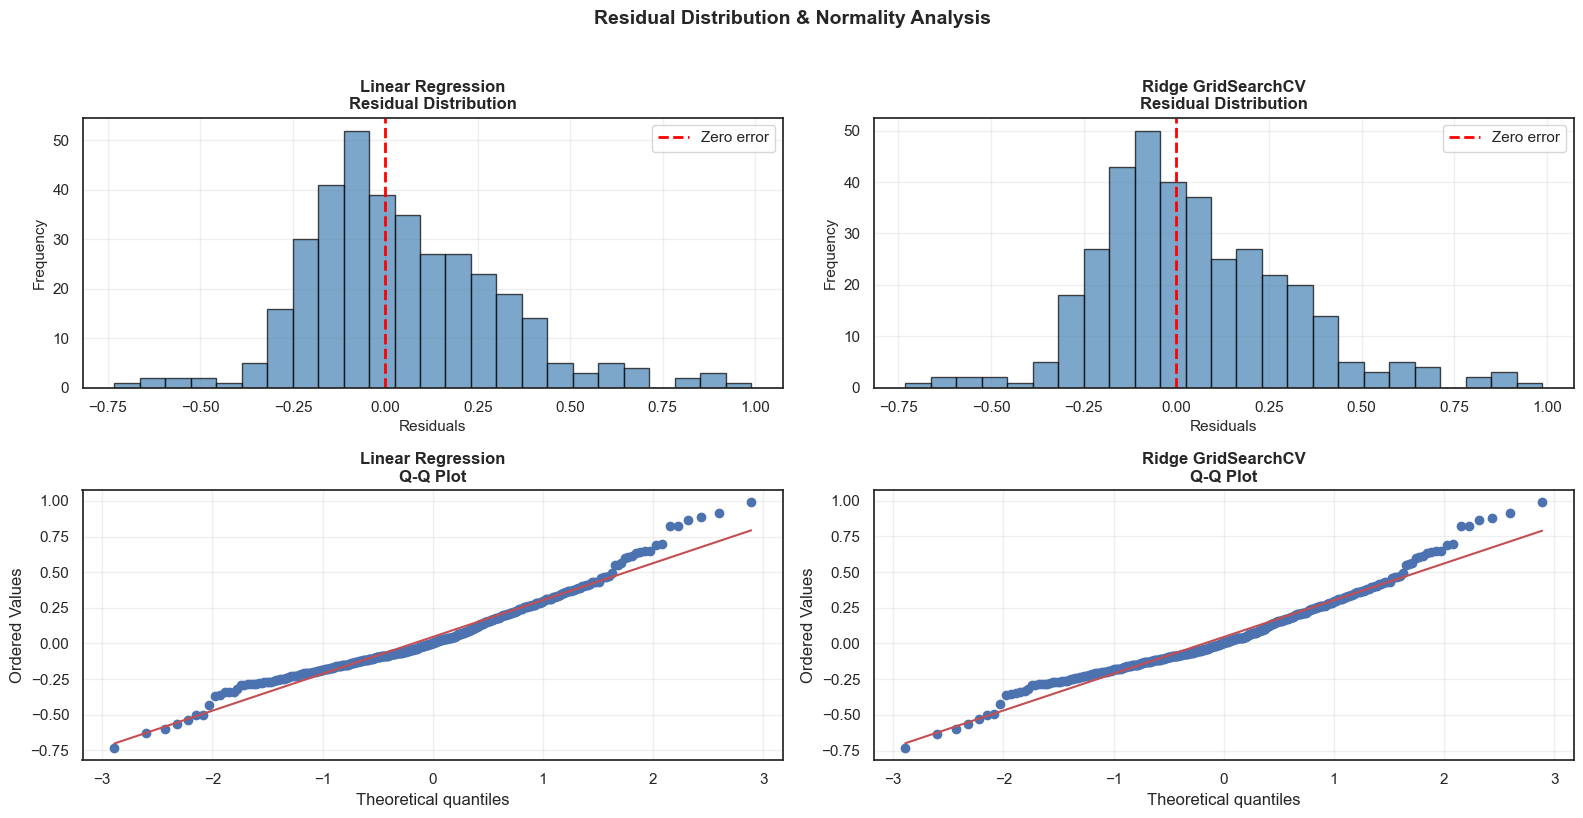


NORMALITY TEST - RESIDUALS (Shapiro-Wilk Test)
H0: Residuals are normally distributed
If p-value > 0.05, residuals are likely normally distributed

Linear Regression:
  Test Statistic: 0.967946
  P-value: 0.000000
  Result: Residuals deviate from normality

Ridge GridSearchCV:
  Test Statistic: 0.967412
  P-value: 0.000000
  Result: Residuals deviate from normality



In [17]:
from scipy import stats

# Residual Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for idx, (model_name, residuals) in enumerate(zip(models, residuals_list)):
    # Histogram
    ax_hist = axes[0, idx]
    ax_hist.hist(residuals, bins=25, alpha=0.7, color='steelblue', edgecolor='black')
    ax_hist.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
    ax_hist.set_xlabel('Residuals', fontsize=11)
    ax_hist.set_ylabel('Frequency', fontsize=11)
    ax_hist.set_title(
        f'{model_name}\nResidual Distribution', fontsize=12, fontweight='bold'
    )
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # Q-Q Plot
    ax_qq = axes[1, idx]
    stats.probplot(residuals, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{model_name}\nQ-Q Plot', fontsize=12, fontweight='bold')
    ax_qq.grid(True, alpha=0.3)

plt.suptitle(
    'Residual Distribution & Normality Analysis', fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("NORMALITY TEST - RESIDUALS (Shapiro-Wilk Test)")
print("=" * 60)
print("H0: Residuals are normally distributed")
print("If p-value > 0.05, residuals are likely normally distributed\n")

for model_name, residuals in zip(models, residuals_list):
    stat, p_value = stats.shapiro(residuals)
    print(f"{model_name}:")
    print(f"  Test Statistic: {stat:.6f}")
    print(f"  P-value: {p_value:.6f}")
    print(
        f"  Result: {'Residuals are normally distributed ✓' if p_value > 0.05 else 'Residuals deviate from normality'}\n"
    )